In [20]:
import tensorflow as tf
from tensorflow.keras import layers
import numpy as np
import matplotlib.pyplot as plt

# 1. Load Fashion-MNIST dataset

In [21]:


(x_train, _), (_, _) = tf.keras.datasets.fashion_mnist.load_data()


# Normalize pixel values from [0, 255] to [-1, 1]
# Because the Generator uses tanh activation at its output.
x_train = (x_train.astype("float32") - 127.5) / 127.5


# Flatten each 28x28 image into a vector of 784 values
x_train = x_train.reshape(-1, 784)

In [22]:
x_train.shape

(60000, 784)

# 2. Hyperparameters

In [23]:
latent_dim = 100
batch_size = 128
epochs = 30

# 3. Generator

In [24]:
generator = tf.keras.Sequential([
    layers.Input(shape=(latent_dim,)),

    layers.Dense(256),
    layers.LeakyReLU(negative_slope=0.2),

    layers.Dense(512),
    layers.LeakyReLU(negative_slope=0.2),

    layers.Dense(1024),
    layers.LeakyReLU(negative_slope=0.2),

    # 784 values = 28 x 28 image
    layers.Dense(784, activation="tanh")
])


generator.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_8 (Dense)                 │ (None, 256)            │        25,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_6 (LeakyReLU)       │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 512)            │       131,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_7 (LeakyReLU)       │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 1024)           │       525,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_8 (LeakyReLU)       │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 784)            │       803,600 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,486,352 (5.67 MB)

 Trainable params: 1,486,352 (5.67 MB)

 Non-trainable params: 0 (0.00 B)

# 4. Discriminator

In [25]:
discriminator = tf.keras.Sequential([
    layers.Input(shape=(784,)),

    layers.Dense(1024),
    layers.LeakyReLU(negative_slope=0.2),

    layers.Dense(512),
    layers.LeakyReLU(negative_slope=0.2),

    layers.Dense(256),
    layers.LeakyReLU(negative_slope=0.2),

    # Output probability:
    # close to 1 = real
    # close to 0 = fake
    layers.Dense(1, activation="sigmoid")
])


discriminator.summary()


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_12 (Dense)                │ (None, 1024)           │       803,840 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_9 (LeakyReLU)       │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 512)            │       524,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_10 (LeakyReLU)      │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_11 (LeakyReLU)      │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,460,225 (5.57 MB)

 Trainable params: 1,460,225 (5.57 MB)

 Non-trainable params: 0 (0.00 B)

# 5. GAN Model

In [27]:
class GAN(tf.keras.Model):

    def __init__(self, generator, discriminator):

        super().__init__()

        self.generator = generator
        self.discriminator = discriminator

        self.d_loss_tracker = tf.keras.metrics.Mean(name="d_loss")
        self.g_loss_tracker = tf.keras.metrics.Mean(name="g_loss")


    @property
    def metrics(self):

        return [
            self.d_loss_tracker,
            self.g_loss_tracker
        ]


    def compile(self, d_optimizer, g_optimizer, loss_fn):

        super().compile()

        self.d_optimizer = d_optimizer
        self.g_optimizer = g_optimizer
        self.loss_fn = loss_fn


    def train_step(self, real_images):

        # Number of images in current batch
        batch_size = tf.shape(real_images)[0]


        # ====================================================
        # PART 1: Train Discriminator
        # ====================================================

        # Generate random noise
        random_latent_vectors = tf.random.normal(
            shape=(batch_size, latent_dim)
        )


        # Generate fake images
        generated_images = self.generator(
            random_latent_vectors,
            training=True
        )


        # Combine:
        #
        # fake images first
        # real images second
        #
        combined_images = tf.concat(
            [generated_images, real_images],
            axis=0
        )


        # Labels:
        #
        # fake = 0
        # real = 1
        #
        labels = tf.concat(
            [
                tf.zeros((batch_size, 1)),
                tf.ones((batch_size, 1))
            ],
            axis=0
        )


        # Small amount of label noise
        labels += 0.05 * tf.random.uniform(
            tf.shape(labels)
        )


        # Calculate discriminator loss
        with tf.GradientTape() as tape:

            predictions = self.discriminator(
                combined_images,
                training=True
            )

            d_loss = self.loss_fn(
                labels,
                predictions
            )


        # Calculate gradients
        grads = tape.gradient(
            d_loss,
            self.discriminator.trainable_weights
        )


        # Update discriminator
        self.d_optimizer.apply_gradients(
            zip(
                grads,
                self.discriminator.trainable_weights
            )
        )


        # ====================================================
        # PART 2: Train Generator
        # ====================================================

        # Generate new random noise
        random_latent_vectors = tf.random.normal(
            shape=(batch_size, latent_dim)
        )


        # The generator wants the discriminator
        # to classify fake images as REAL.
        #
        # Therefore target = 1
        misleading_labels = tf.ones(
            (batch_size, 1)
        )


        # Calculate generator loss
        with tf.GradientTape() as tape:

            generated_images = self.generator(
                random_latent_vectors,
                training=True
            )


            predictions = self.discriminator(
                generated_images,
                training=True
            )


            g_loss = self.loss_fn(
                misleading_labels,
                predictions
            )


        # Calculate generator gradients
        grads = tape.gradient(
            g_loss,
            self.generator.trainable_weights
        )


        # Update generator
        self.g_optimizer.apply_gradients(
            zip(
                grads,
                self.generator.trainable_weights
            )
        )


        # ====================================================
        # Track losses
        # ====================================================

        self.d_loss_tracker.update_state(d_loss)
        self.g_loss_tracker.update_state(g_loss)


        return {
            "d_loss": self.d_loss_tracker.result(),
            "g_loss": self.g_loss_tracker.result()
        }


# 6. Create GAN

In [28]:
gan = GAN(
    generator,
    discriminator
)

# 7. Compile GAN

In [29]:
gan.compile(

    d_optimizer=tf.keras.optimizers.Adam(
        learning_rate=0.0002,
        beta_1=0.5
    ),

    g_optimizer=tf.keras.optimizers.Adam(
        learning_rate=0.0002,
        beta_1=0.5
    ),

    loss_fn=tf.keras.losses.BinaryCrossentropy()
)


# 8. Train GAN

In [30]:
history = gan.fit(
    x_train,
    epochs=epochs,
    batch_size=batch_size
)

Epoch 1/30
469/469 ━━━━━━━━━━━━━━━━━━━━ 9s 10ms/step - d_loss: 0.3776 - g_loss: 1.7110
Epoch 2/30
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - d_loss: 0.4278 - g_loss: 1.7343
Epoch 3/30
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - d_loss: 0.4486 - g_loss: 1.6075
Epoch 4/30
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - d_loss: 0.4751 - g_loss: 1.5149
Epoch 5/30
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - d_loss: 0.4919 - g_loss: 1.4133
Epoch 6/30
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - d_loss: 0.4956 - g_loss: 1.4052
Epoch 7/30
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - d_loss: 0.4970 - g_loss: 1.3618
Epoch 8/30
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - d_loss: 0.4910 - g_loss: 1.3647
Epoch 9/30
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - d_loss: 0.4980 - g_loss: 1.3418
Epoch 10/30
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - d_loss: 0.4947 - g_loss: 1.3172
Epoch 11/30
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - d_loss: 0.4754 - g_loss: 1.3254
Epoch 12/30
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/ste

# 9. Plot losses

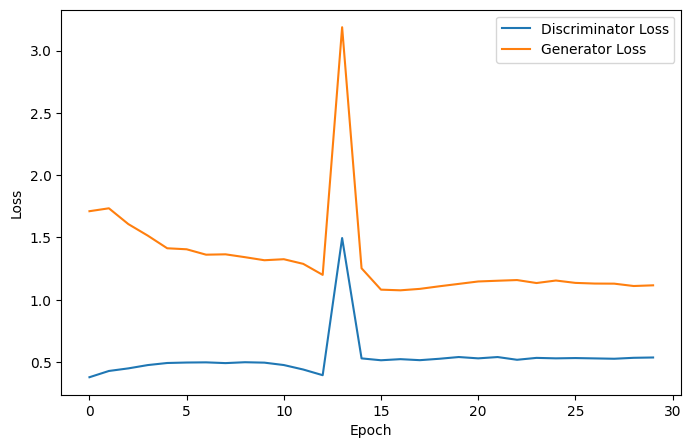

In [31]:
plt.figure(figsize=(8, 5))

plt.plot(
    history.history["d_loss"],
    label="Discriminator Loss"
)

plt.plot(
    history.history["g_loss"],
    label="Generator Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.show()


# 10. Generate new images

In [32]:
num_images = 16


# Generate 16 random 100-dimensional vectors
noise = tf.random.normal(
    shape=(num_images, latent_dim)
)


# Pass noise through Generator
generated_images = generator.predict(
    noise,
    verbose=0
)


# Convert 784 values back to 28x28
generated_images = generated_images.reshape(
    num_images,
    28,
    28
)


# Convert [-1, 1] back to [0, 1]
generated_images = (
    generated_images + 1
) / 2.0


# 11. Display generated images

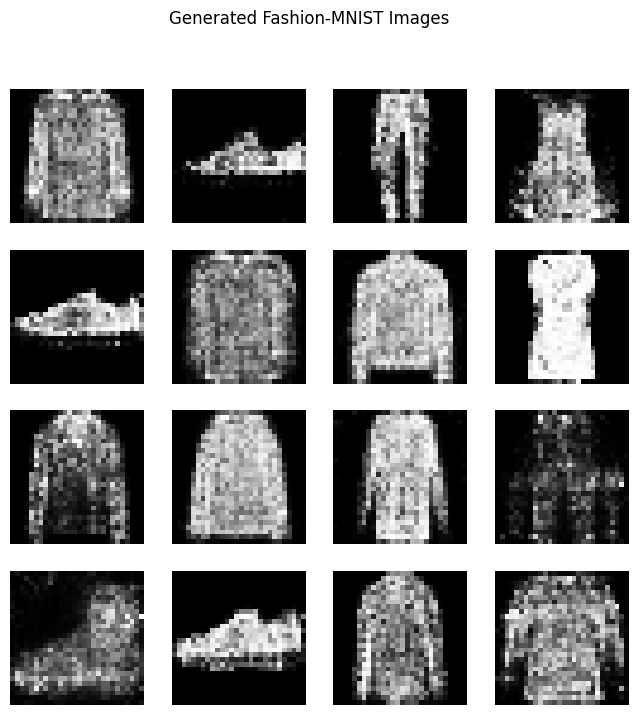

In [33]:
plt.figure(figsize=(8, 8))

for i in range(num_images):

    plt.subplot(4, 4, i + 1)

    plt.imshow(
        generated_images[i],
        cmap="gray"
    )

    plt.axis("off")


plt.suptitle("Generated Fashion-MNIST Images")

plt.show()
